# Lesson 8: Forward modeling and dipoles

Neurocampus course "Signals of the whole brain"

Daria Kleeva

dkleeva@gmail.com

May 6th, 2026


## FreeSurfer

In [ ]:
# export FREESURFER_HOME=/Applications/freesurfer
# export SUBJECTS_DIR=$FREESURFER_HOME/subjects
# source $FREESURFER_HOME/SetUpFreeSurfer.sh 
# mri_convert "/Users/dkleeva/Desktop/SubjectName/SubjectName_MRI/IMG-0003-00001.dcm" SUBJECTS_DIR/SubjectName.nii.gz
# recon-all -i $SUBJECTS_DIR/SubjectName.nii.gz -subjid SubjectName
# recon-all -all -subjid SubjectName -parallel -openmp 8

In [ ]:
# import mne
# from mne.bem import make_watershed_bem
# fs='/Applications/freesurfer/subjects/'
# mne.bem.make_watershed_bem('SubjectName', subjects_dir=fs, overwrite=True, volume='T1', 
#                            atlas=False, gcaatlas=False, preflood=None, show=False, copy=False, T1=None, brainmask='ws.mgz', verbose=None)

## Import

In [1]:
import mne
from mne import io
import matplotlib.pyplot as plt
import numpy as np

from mne.simulation import simulate_raw, add_noise
from mne.datasets import sample
import seaborn as sns

In [2]:
from mne.datasets import sample
data_path = sample.data_path()
raw_fname = str(data_path) + '/MEG/sample/sample_audvis_raw.fif'
event_fname = str(data_path) + '/MEG/sample/sample_audvis_raw-eve.fif'

In [3]:
raw = mne.io.read_raw_fif(raw_fname, preload=True)
events = mne.read_events(event_fname)

Opening raw data file /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


In [4]:
import os.path as op
subjects_dir = op.join(data_path, 'subjects')

## Spherical head model

In [5]:
meg_info = raw.copy().pick('mag').info
sphere = mne.make_sphere_model(
    r0='auto',          
    head_radius='auto',  
    info=meg_info,
)

Fitted sphere radius:         91.0 mm
Origin head coordinates:      -4.1 16.0 51.8 mm
Origin device coordinates:    1.4 17.8 -10.3 mm

Equiv. model fitting -> RV = 0.00348741 %%
mu1 = 0.94474    lambda1 = 0.137123
mu2 = 0.667472    lambda2 = 0.683828
mu3 = -0.266864    lambda3 = -0.0105809
Set up EEG sphere model with scalp radius    91.0 mm



In [6]:
r0 = sphere['r0']

In [7]:
true_pos_rel = np.array([0.028, -0.045, -0.010])  # meters, offset from r0
true_pos = (r0 + true_pos_rel).reshape(1, 3)

In [8]:
distance_from_center = np.linalg.norm(true_pos_rel) * 1000
print(f"Position of dipole: {true_pos[0]*1000} mm")
print(f"Distance from center: {distance_from_center:.1f} mm")
print(f"(brain radius in our model: {sphere['layers'][0]['rad']*1000:.1f} mm)")

Position of dipole: [ 23.87270387 -29.01387441  41.75860955] mm
Distance from center: 53.9 mm
(brain radius in our model: 81.9 mm)


In [9]:
def make_tangent(pos_rel, template):
    """Make a tangent vector to the sphere at a given point."""
    radial = pos_rel / np.linalg.norm(pos_rel)
    template = np.asarray(template, dtype=float)
    tangent = template - np.dot(template, radial) * radial
    return tangent / np.linalg.norm(tangent)

In [10]:
true_ori = make_tangent(true_pos_rel, [0, 1, 0]).reshape(1, 3)
print(f"\nOrientation of dipole: {true_ori[0]}")


Orientation of dipole: [ 0.78572858  0.5512572  -0.28061735]


In [11]:
true_amp = 50e-9  # A·m
true_dipole = mne.Dipole(
    times=np.array([0.0]),                    # one moment in time
    pos=true_pos,                            # position
    amplitude=np.array([true_amp]),          # amplitude
    ori=true_ori,                            # orientation
    gof=np.array([100.0]),                   # GOF — now not important
)

In [12]:
fwd_one, _ = mne.make_forward_dipole(
    dipole=true_dipole,
    bem=sphere,
    info=meg_info,
    trans=None,   # for a spherical model, coordinates coincide
)

Positions (in meters) and orientations
1 sources
Source space          : <SourceSpaces: [<discrete, n_used=1>] head coords, ~2 kB>
MRI -> head transform : identity
Measurement data      : instance of Info
Sphere model      : origin at [-0.0041273   0.01598613  0.05175861] mm
Standard field computations
Do computations in head coordinates
Free source orientations

Read 1 source spaces a total of 1 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    1.000000 0.000000 0.000000       0.00 mm
    0.000000 1.000000 0.000000       0.00 mm
    0.000000 0.000000 1.000000       0.00 mm
    0.000000 0.000000 0.000000       1.00

Read 102 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
MEG coil definitions created in head coordinates.
Source spa

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.3s finished


In [13]:
G_one = fwd_one['sol']['data']

Signal on MEG sensors:
  range: [-0.00, 0.00] μV
  mean:  0.00 μV
  RMS:      0.00 μV


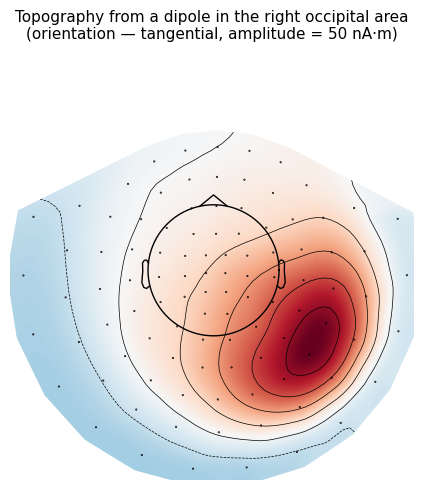

In [14]:
m_meg = (G_one * true_amp).ravel()   # (n_channels,) in volts
 

m_meg_fmt = m_meg * 1e6
print(f"Signal on MEG sensors:")
print(f"  range: [{m_meg_fmt.min():.2f}, {m_meg_fmt.max():.2f}] μV")
print(f"  mean:  {m_meg_fmt.mean():.2f} μV")
print(f"  RMS:      {np.sqrt(np.mean(m_meg_fmt**2)):.2f} μV")
 

fig, ax = plt.subplots(figsize=(5, 5))
mne.viz.plot_topomap(
    m_meg_fmt, meg_info, axes=ax, show=False,
    cmap='RdBu_r', sensors=True, contours=6,
    sphere=sphere,
)
ax.set_title(f'Topography from a dipole in the right occipital area\n'
             f'(orientation — tangential, amplitude = {true_amp*1e9:.0f} nA·m)',
             fontsize=11)
plt.tight_layout()
plt.show()

## Dipoles parameters

In [15]:
def topo_from_dipole(pos_rel, ori_template, amp, info, sphere):
    pos_rel = np.asarray(pos_rel, dtype=float)
    pos = (sphere['r0'] + pos_rel).reshape(1, 3)
    ori = make_tangent(pos_rel, ori_template).reshape(1, 3)
    dip = mne.Dipole(
        times=np.array([0.0]), pos=pos,
        amplitude=np.array([amp]),
        ori=ori, gof=np.array([100.0]),
    )
    fwd, _ = mne.make_forward_dipole(dip, sphere, info)
    topo = (fwd['sol']['data'] * amp).ravel()
    return topo, pos, ori

Positions (in meters) and orientations
1 sources
Source space          : <SourceSpaces: [<discrete, n_used=1>] head coords, ~2 kB>
MRI -> head transform : identity
Measurement data      : instance of Info
Sphere model      : origin at [-0.0041273   0.01598613  0.05175861] mm
Standard field computations
Do computations in head coordinates
Free source orientations

Read 1 source spaces a total of 1 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    1.000000 0.000000 0.000000       0.00 mm
    0.000000 1.000000 0.000000       0.00 mm
    0.000000 0.000000 1.000000       0.00 mm
    0.000000 0.000000 0.000000       1.00

Read 102 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
MEG coil definitions created in head coordinates.
Source spa

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


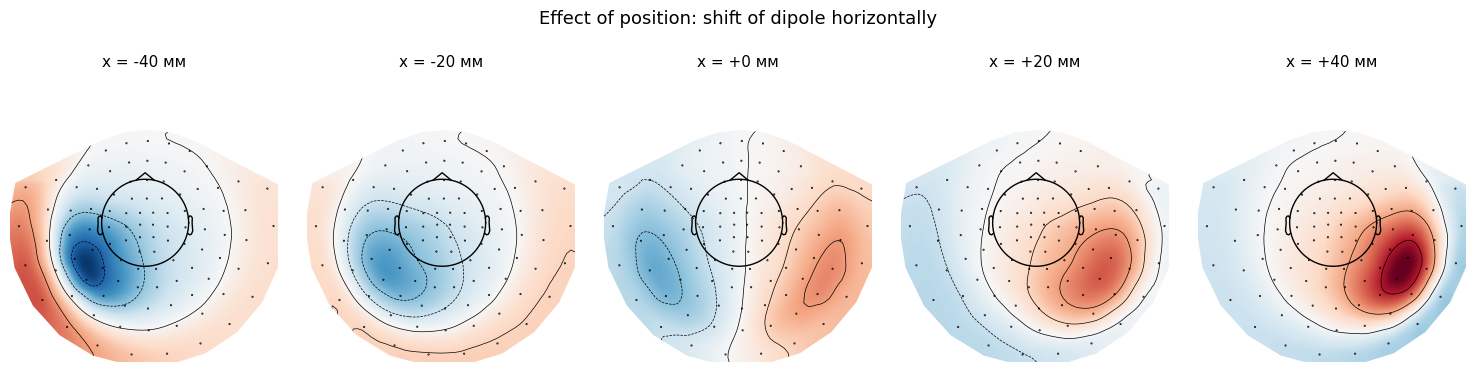

In [16]:
x_positions_mm = np.linspace(-40, 40, 5)   
 
fig, axes = plt.subplots(1, len(x_positions_mm), figsize=(15, 3.5))
 
all_topos_x = []
for x_mm in x_positions_mm:
    pos_rel = np.array([x_mm/1000, -0.045, -0.010])
    topo, _, _ = topo_from_dipole(pos_rel, [0, 1, 0], 50e-9, meg_info, sphere)
    all_topos_x.append(topo)
vmax = np.max(np.abs(all_topos_x)) * 1e6
 
for ax, topo, x_mm in zip(axes, all_topos_x, x_positions_mm):
    mne.viz.plot_topomap(
        topo * 1e6, meg_info, axes=ax, show=False,
        cmap='RdBu_r', vlim=(-vmax, vmax), sphere=sphere,
        sensors=True, contours=4,
    )
    ax.set_title(f'x = {x_mm:+.0f} мм', fontsize=11)
 
fig.suptitle('Effect of position: shift of dipole horizontally', y=1.05, fontsize=13)
plt.tight_layout()
plt.show()

Positions (in meters) and orientations
1 sources
Source space          : <SourceSpaces: [<discrete, n_used=1>] head coords, ~2 kB>
MRI -> head transform : identity
Measurement data      : instance of Info
Sphere model      : origin at [-0.0041273   0.01598613  0.05175861] mm
Standard field computations
Do computations in head coordinates
Free source orientations

Read 1 source spaces a total of 1 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    1.000000 0.000000 0.000000       0.00 mm
    0.000000 1.000000 0.000000       0.00 mm
    0.000000 0.000000 1.000000       0.00 mm
    0.000000 0.000000 0.000000       1.00

Read 102 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
MEG coil definitions created in head coordinates.
Source spa

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


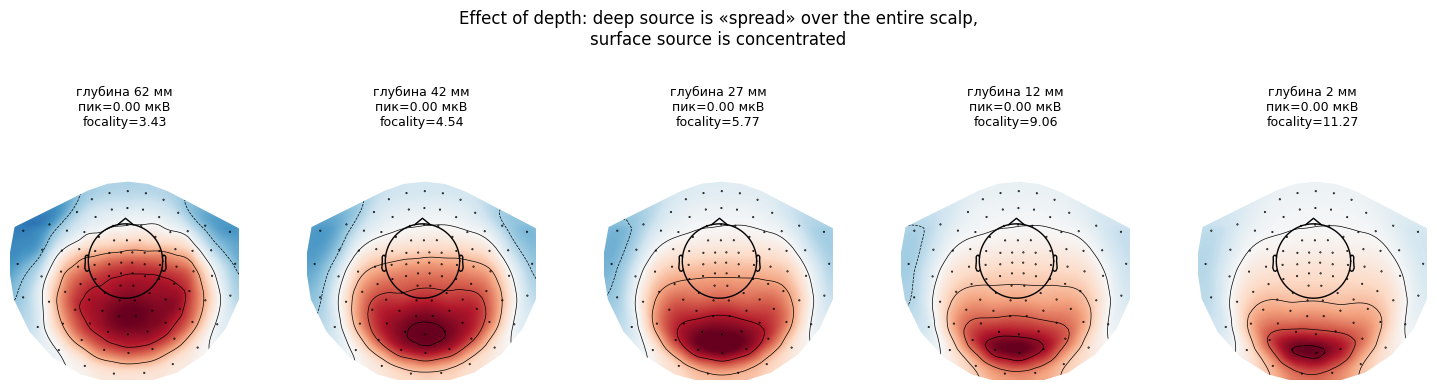

In [17]:
distances_mm = [20, 40, 55, 70, 80]   
brain_radius_mm = sphere['layers'][0]['rad'] * 1000
 
fig, axes = plt.subplots(1, len(distances_mm), figsize=(15, 3.5))
 
all_topos_depth = []
for d_mm in distances_mm:
    direction = np.array([0., -0.5, -0.3])
    direction /= np.linalg.norm(direction)
    pos_rel = direction * d_mm / 1000
    topo, _, _ = topo_from_dipole(pos_rel, [1, 0, 0], 50e-9, meg_info, sphere)
    all_topos_depth.append(topo)
 
for ax, topo, d_mm in zip(axes, all_topos_depth, distances_mm):
    depth_from_surface = brain_radius_mm - d_mm
    vmax_local = np.max(np.abs(topo)) * 1e6
    mne.viz.plot_topomap(
        topo * 1e6, meg_info, axes=ax, show=False,
        cmap='RdBu_r', vlim=(-vmax_local, vmax_local),
        sphere=sphere, sensors=True, contours=4,
    )
    peak = np.max(np.abs(topo)) * 1e6
    focality = (np.max(topo**2) / np.sum(topo**2)) * len(topo)
    ax.set_title(f'глубина {depth_from_surface:.0f} мм\n'
                 f'пик={peak:.2f} мкВ\n'
                 f'focality={focality:.2f}', fontsize=9)
 
fig.suptitle('Effect of depth: deep source is «spread» over the entire scalp,\n'
             'surface source is concentrated',
             y=1.10, fontsize=12)
plt.tight_layout()
plt.show()

Positions (in meters) and orientations
1 sources
Source space          : <SourceSpaces: [<discrete, n_used=1>] head coords, ~2 kB>
MRI -> head transform : identity
Measurement data      : instance of Info
Sphere model      : origin at [-0.0041273   0.01598613  0.05175861] mm
Standard field computations
Do computations in head coordinates
Free source orientations

Read 1 source spaces a total of 1 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    1.000000 0.000000 0.000000       0.00 mm
    0.000000 1.000000 0.000000       0.00 mm
    0.000000 0.000000 1.000000       0.00 mm
    0.000000 0.000000 0.000000       1.00

Read 102 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
MEG coil definitions created in head coordinates.
Source spa

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


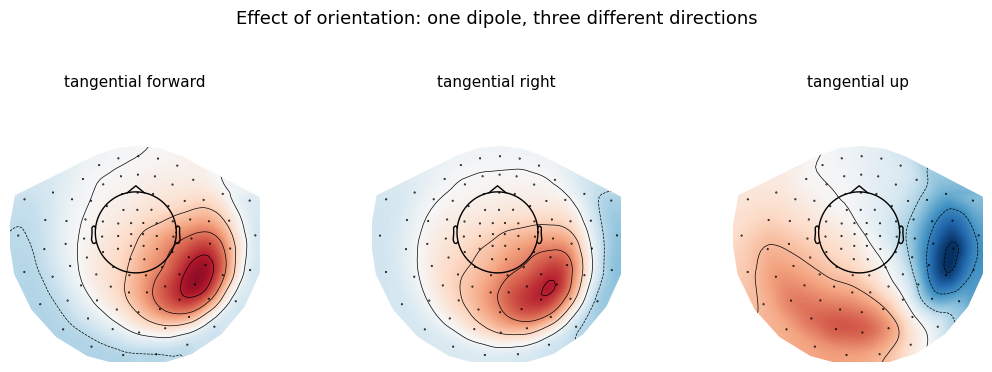

In [18]:
ori_templates = [
    ('tangential forward', [0, 1, 0]),
    ('tangential right', [1, 0, 0]),
    ('tangential up',  [0, 0, 1]),
]
 
pos_rel_fixed = np.array([0.028, -0.045, -0.010])
 
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
all_topos_ori = []
for label, tmpl in ori_templates:
    topo, _, _ = topo_from_dipole(pos_rel_fixed, tmpl, 50e-9, meg_info, sphere)
    all_topos_ori.append(topo)
 
vmax_ori = np.max(np.abs(all_topos_ori)) * 1e6
 
for ax, (label, _), topo in zip(axes, ori_templates, all_topos_ori):
    mne.viz.plot_topomap(
        topo * 1e6, meg_info, axes=ax, show=False,
        cmap='RdBu_r', vlim=(-vmax_ori, vmax_ori),
        sphere=sphere, sensors=True, contours=5,
    )
    ax.set_title(label, fontsize=11)
 
fig.suptitle('Effect of orientation: one dipole, three different directions',
             y=1.05, fontsize=13)
plt.tight_layout()
plt.show()

## Compute BEM model and solution

In [19]:
src = mne.setup_source_space('sample', spacing='ico4',
                                 subjects_dir=subjects_dir)
model = mne.make_bem_model(subject='sample', ico=4, conductivity=[0.3, 0.006, 0.3],
                               subjects_dir=subjects_dir)
bem = mne.make_bem_solution(model)

Setting up the source space with the following parameters:

SUBJECTS_DIR = /Users/dkleeva/mne_data/MNE-sample-data/subjects
Subject      = sample
Surface      = white
Icosahedron subdivision grade 4

>>> 1. Creating the source space...

Doing the icosahedral vertex picking...
Loading /Users/dkleeva/mne_data/MNE-sample-data/subjects/sample/surf/lh.white...
Mapping lh sample -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from /Users/dkleeva/mne_data/MNE-sample-data/subjects/sample/surf/lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 2562/155407 selected to source space (ico = 4)

Loading /Users/dkleeva/mne_data/MNE-sample-data/subjects/sample/surf/rh.white...
Mapping rh sample -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from /Users/dkleeva/mne_data/MNE-sample-data/subjects/sample/surf/rh.sphere...
Setting up the triangulation for the decimated surface...
loaded rh.white 2562/156866 selec

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.2min finished


    Computing patch statistics...
    Patch information added...
    Computing patch statistics...
    Patch information added...
You are now one step closer to computing the gain matrix
Creating the BEM geometry...
Going from 4th to 4th subdivision of an icosahedron (n_tri: 5120 -> 5120)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.2min finished


Going from 4th to 4th subdivision of an icosahedron (n_tri: 5120 -> 5120)
Going from 4th to 4th subdivision of an icosahedron (n_tri: 5120 -> 5120)
outer skin  CM is  -0.12  -0.14  22.79 mm
outer skull CM is   0.70  -9.88  44.01 mm
inner skull CM is   0.67 -10.01  44.26 mm
Checking that surface outer skull is inside surface outer skin  ...
Checking that surface inner skull is inside surface outer skull ...
Checking distance between outer skin  and outer skull surfaces...
Minimum distance between the outer skin  and outer skull surfaces is approximately    3.7 mm
Checking distance between outer skull and inner skull surfaces...
Minimum distance between the outer skull and inner skull surfaces is approximately    3.5 mm
Surfaces passed the basic topology checks.
Complete.

Three-layer model surfaces loaded.
Computing the linear collocation solution...
    Matrix coefficients...
        outer skin  (2562) -> outer skin  (2562) ...
        outer skin  (2562) -> outer skull (2562) ...
     

Using surface: /Users/dkleeva/mne_data/MNE-sample-data/subjects/sample/bem/inner_skull.surf
Using surface: /Users/dkleeva/mne_data/MNE-sample-data/subjects/sample/bem/outer_skull.surf
Using surface: /Users/dkleeva/mne_data/MNE-sample-data/subjects/sample/bem/outer_skin.surf


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


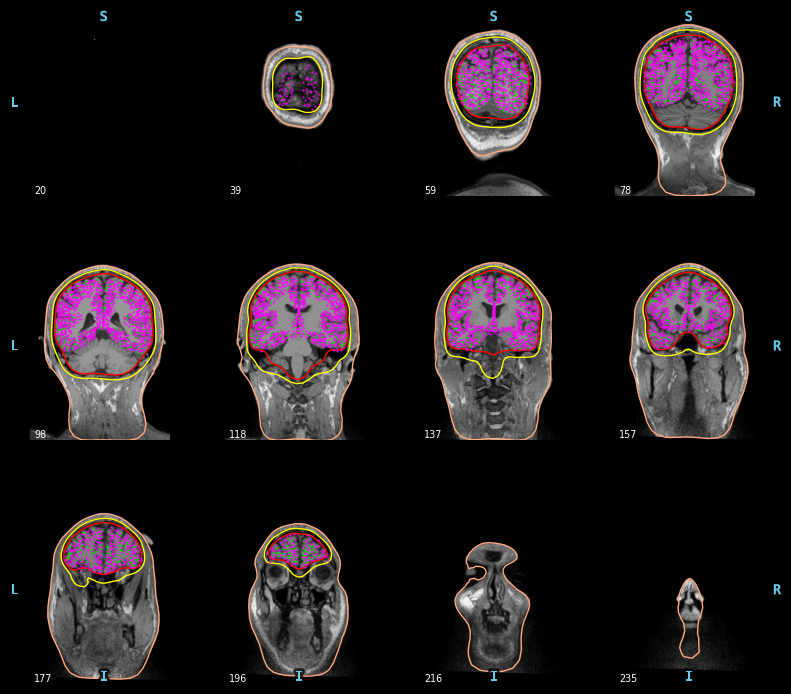

In [20]:
fig = mne.viz.plot_bem(subject='sample', subjects_dir=subjects_dir,
                 brain_surfaces='white', orientation='coronal', src=src)

In [21]:
src

<SourceSpaces: [<surface (lh), n_vertices=155407, n_used=2562>, <surface (rh), n_vertices=156866, n_used=2562>] MRI (surface RAS) coords, subject 'sample', ~33.0 MB>

In [22]:
src[0]

{'rr': array([[-0.02095193, -0.08627678,  0.01324033],
        [-0.02110974, -0.08622514,  0.01331493],
        [-0.02139933, -0.08605659,  0.01338905],
        ...,
        [-0.01231463,  0.0725397 ,  0.05550697],
        [-0.01401764,  0.07201006,  0.0569932 ],
        [-0.01484421,  0.0722774 ,  0.05620262]]),
 'tris': array([[     0,      1,      3],
        [     4,      3,      1],
        [     0,     61,     62],
        ...,
        [153723, 153732, 153919],
        [153900, 153907, 153901],
        [154073, 154322, 154245]], dtype='>i4'),
 'ntri': 310810,
 'use_tris': array([[ 71573,  73855,  71442],
        [ 71442,  72684,  72571],
        [ 73855,  72684,  71442],
        ...,
        [ 98882,  98839, 107924],
        [ 92015,  98839,  98882],
        [ 92015,  88406,  98839]], dtype=int32),
 'np': 155407,
 'nn': array([[-0.01874355, -0.95650626,  0.291109  ],
        [-0.39538466, -0.91271418,  0.10307183],
        [-0.42436735, -0.90215294, -0.07766874],
        ...,
   

In [23]:
src[0]['rr']

array([[-0.02095193, -0.08627678,  0.01324033],
       [-0.02110974, -0.08622514,  0.01331493],
       [-0.02139933, -0.08605659,  0.01338905],
       ...,
       [-0.01231463,  0.0725397 ,  0.05550697],
       [-0.01401764,  0.07201006,  0.0569932 ],
       [-0.01484421,  0.0722774 ,  0.05620262]])

In [24]:
src[0]['vertno']

array([    59,    153,    236, ..., 155087, 155192, 155377])

In [25]:
src[0]['nn']

array([[-0.01874355, -0.95650626,  0.291109  ],
       [-0.39538466, -0.91271418,  0.10307183],
       [-0.42436735, -0.90215294, -0.07766874],
       ...,
       [ 0.32397546,  0.32694985,  0.88777458],
       [ 0.53388722,  0.56742684,  0.62689012],
       [-0.85292747,  0.3917218 , -0.34506343]])

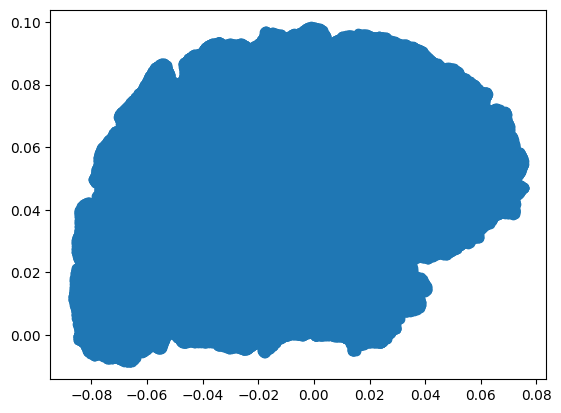

In [26]:
plt.scatter(src[0]['rr'][:,1], src[0]['rr'][:,2])
plt.show()

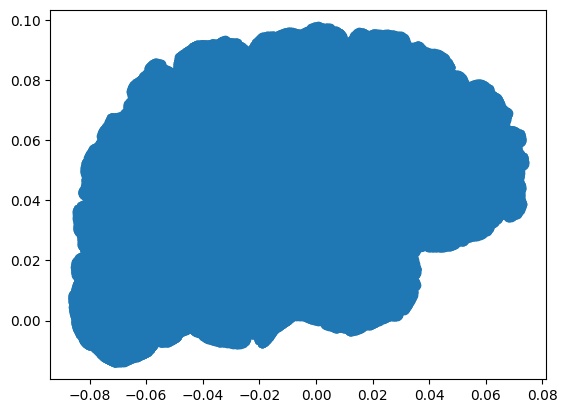

In [27]:
plt.scatter(src[1]['rr'][:,1], src[1]['rr'][:,2])
plt.show()

In [28]:
src[0]['nn']

array([[-0.01874355, -0.95650626,  0.291109  ],
       [-0.39538466, -0.91271418,  0.10307183],
       [-0.42436735, -0.90215294, -0.07766874],
       ...,
       [ 0.32397546,  0.32694985,  0.88777458],
       [ 0.53388722,  0.56742684,  0.62689012],
       [-0.85292747,  0.3917218 , -0.34506343]])

## Coregistration

In [29]:
mne.gui.coregistration(subject='sample', subjects_dir=subjects_dir)

Using pyvistaqt 3d backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
    Triangle neighbors and vertex normals...
Using high resolution head model in /Users/dkleeva/mne_data/MNE-sample-data/subjects/sample/surf/lh.seghead
    Triangle neighbors and vertex normals...
Estimating fiducials from fsaverage.
    Triangle neighbors and vertex normals...
Using high resolution head model in /Users/dkleeva/mne_data/MNE-sample-data/subjects/sample/surf/lh.seghead
    Triangle neighbors and vertex normals...
Estimating fiducials from fsaverage.
Estimating fiducials from fsaverage.
Placing MRI fiducials - LPA
Using lh.seghead for head surface.
Placing MRI fiducials - LPA


In [30]:
trans = str(data_path) + '/MEG/sample/sample_audvis_raw-trans.fif'

In [31]:
info = mne.io.read_info(raw_fname)
mne.viz.plot_alignment(info, trans, subject='sample', dig=True,
                       meg=['helmet', 'sensors'], subjects_dir=subjects_dir,
                       surfaces='head-dense')

    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
Using lh.seghead for head surface.
Getting helmet for system 306m
Channel types::	grad: 203, mag: 102, eeg: 59


## Compute forward solution

In [32]:
fwd = mne.make_forward_solution(raw_fname, trans=trans, src=src, bem=bem,
                                meg=True, eeg=True, mindist=5.0, n_jobs=1,
                                verbose=True)

Source space          : <SourceSpaces: [<surface (lh), n_vertices=155407, n_used=2562>, <surface (rh), n_vertices=156866, n_used=2562>] MRI (surface RAS) coords, subject 'sample', ~33.0 MB>
MRI -> head transform : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
Measurement data      : sample_audvis_raw.fif
Conductor model   : instance of ConductorModel
Accurate field computations
Do computations in head coordinates
Free source orientations

Read 2 source spaces a total of 5124 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    0.999310 0.009985 -0.035787      -3.17 mm
    0.012759 0.812405 0.582954       6.86 mm
    0.034894 -0.583008 0.811716      28.88 mm
    0.000000 0.000000 0.000000       1.00

Read 306 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991  

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Setting up for EEG...
Computing MEG at 4699 source locations (free orientations)...


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/forward/_compute_forward.py:256: RuntimeWarning: divide by zero encountered in matmul
  weights = np.matmul(
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/forward/_compute_forward.py:256: RuntimeWarning: overflow encountered in matmul
  weights = np.matmul(
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/forward/_compute_forward.py:256: RuntimeWarning: invalid value encountered in matmul
  weights = np.matmul(


Computing EEG at 4699 source locations (free orientations)...

Finished.


In [33]:
leadfield = fwd['sol']['data']

In [34]:
leadfield.shape

(366, 14097)

In [35]:
leadfield.shape[1]/3

4699.0

In [36]:
fwd

Magnetometers,"<button class=""channel-names-btn"" onclick=""alert('Good Magnetometers:\n\nMEG 0111, MEG 0121, MEG 0131, MEG 0141, MEG 0211, MEG 0221, MEG 0231, MEG 0241, MEG 0311, MEG 0321, MEG 0331, MEG 0341, MEG 0411, MEG 0421, MEG 0431, MEG 0441, MEG 0511, MEG 0521, MEG 0531, MEG 0541, MEG 0611, MEG 0621, MEG 0631, MEG 0641, MEG 0711, MEG 0721, MEG 0731, MEG 0741, MEG 0811, MEG 0821, MEG 0911, MEG 0921, MEG 0931, MEG 0941, MEG 1011, MEG 1021, MEG 1031, MEG 1041, MEG 1111, MEG 1121, MEG 1131, MEG 1141, MEG 1211, MEG 1221, MEG 1231, MEG 1241, MEG 1311, MEG 1321, MEG 1331, MEG 1341, MEG 1411, MEG 1421, MEG 1431, MEG 1441, MEG 1511, MEG 1521, MEG 1531, MEG 1541, MEG 1611, MEG 1621, MEG 1631, MEG 1641, MEG 1711, MEG 1721, MEG 1731, MEG 1741, MEG 1811, MEG 1821, MEG 1831, MEG 1841, MEG 1911, MEG 1921, MEG 1931, MEG 1941, MEG 2011, MEG 2021, MEG 2031, MEG 2041, MEG 2111, MEG 2121, MEG 2131, MEG 2141, MEG 2211, MEG 2221, MEG 2231, MEG 2241, MEG 2311, MEG 2321, MEG 2331, MEG 2341, MEG 2411, MEG 2421, MEG 2431, MEG 2441, MEG 2511, MEG 2521, MEG 2531, MEG 2541, MEG 2611, MEG 2621, MEG 2631, MEG 2641')"" title=""Show good channel names""> 102"
Gradiometers,"<button class=""channel-names-btn"" onclick=""alert('Good Gradiometers:\n\nMEG 0113, MEG 0112, MEG 0122, MEG 0123, MEG 0132, MEG 0133, MEG 0143, MEG 0142, MEG 0213, MEG 0212, MEG 0222, MEG 0223, MEG 0232, MEG 0233, MEG 0243, MEG 0242, MEG 0313, MEG 0312, MEG 0322, MEG 0323, MEG 0333, MEG 0332, MEG 0343, MEG 0342, MEG 0413, MEG 0412, MEG 0422, MEG 0423, MEG 0432, MEG 0433, MEG 0443, MEG 0442, MEG 0513, MEG 0512, MEG 0523, MEG 0522, MEG 0532, MEG 0533, MEG 0542, MEG 0543, MEG 0613, MEG 0612, MEG 0622, MEG 0623, MEG 0633, MEG 0632, MEG 0642, MEG 0643, MEG 0713, MEG 0712, MEG 0723, MEG 0722, MEG 0733, MEG 0732, MEG 0743, MEG 0742, MEG 0813, MEG 0812, MEG 0822, MEG 0823, MEG 0913, MEG 0912, MEG 0923, MEG 0922, MEG 0932, MEG 0933, MEG 0942, MEG 0943, MEG 1013, MEG 1012, MEG 1023, MEG 1022, MEG 1032, MEG 1033, MEG 1043, MEG 1042, MEG 1112, MEG 1113, MEG 1123, MEG 1122, MEG 1133, MEG 1132, MEG 1142, MEG 1143, MEG 1213, MEG 1212, MEG 1223, MEG 1222, MEG 1232, MEG 1233, MEG 1243, MEG 1242, MEG 1312, MEG 1313, MEG 1323, MEG 1322, MEG 1333, MEG 1332, MEG 1342, MEG 1343, MEG 1412, MEG 1413, MEG 1423, MEG 1422, MEG 1433, MEG 1432, MEG 1442, MEG 1443, MEG 1512, MEG 1513, MEG 1522, MEG 1523, MEG 1533, MEG 1532, MEG 1543, MEG 1542, MEG 1613, MEG 1612, MEG 1622, MEG 1623, MEG 1632, MEG 1633, MEG 1643, MEG 1642, MEG 1713, MEG 1712, MEG 1722, MEG 1723, MEG 1732, MEG 1733, MEG 1743, MEG 1742, MEG 1813, MEG 1812, MEG 1822, MEG 1823, MEG 1832, MEG 1833, MEG 1843, MEG 1842, MEG 1912, MEG 1913, MEG 1923, MEG 1922, MEG 1932, MEG 1933, MEG 1943, MEG 1942, MEG 2013, MEG 2012, MEG 2023, MEG 2022, MEG 2032, MEG 2033, MEG 2042, MEG 2043, MEG 2113, MEG 2112, MEG 2122, MEG 2123, MEG 2133, MEG 2132, MEG 2143, MEG 2142, MEG 2212, MEG 2213, MEG 2223, MEG 2222, MEG 2233, MEG 2232, MEG 2242, MEG 2243, MEG 2312, MEG 2313, MEG 2323, MEG 2322, MEG 2332, MEG 2333, MEG 2343, MEG 2342, MEG 2412, MEG 2413, MEG 2423, MEG 2422, MEG 2433, MEG 2432, MEG 2442, MEG 2512, MEG 2513, MEG 2522, MEG 2523, MEG 2533, MEG 2532, MEG 2543, MEG 2542, MEG 2612, MEG 2613, MEG 2623, MEG 2622, MEG 2633, MEG 2632, MEG 2642, MEG 2643')"" title=""Show good channel names""> 203 and 1 bad"
EEG,"<button class=""channel-names-btn"" onclick=""alert('Good EEG:\n\nEEG 001, EEG 002, EEG 003, EEG 004, EEG 005, EEG 006, EEG 007, EEG 008, EEG 009, EEG 010, EEG 011, EEG 012, EEG 013, EEG 014, EEG 015, EEG 016, EEG 017, EEG 018, EEG 019, EEG 020, EEG 021, EEG 022, EEG 023, EEG 024, EEG 025, EEG 026, EEG 027, EEG 028, EEG 029, EEG 030, EEG 031, EEG 032, EEG 033, EEG 034, EEG 035, EEG 036, EEG 037, EEG 038, EEG 039, EEG 040, EEG 041, EEG 042, EEG 043, EEG 044, EEG 045, EEG 046, EEG 047, EEG 048, EEG 049, EEG 050, EEG 051, EEG 052, EEG 054, EEG 055, EEG 056, EEG 057, EEG 058, EEG 059, EEG 060')"" title=""Show good channel names""> 59 and 1 bad"
Source space,Surface

In [37]:
fwd_fixed = mne.convert_forward_solution(fwd, surf_ori=True, force_fixed=True,
                                         use_cps=True)
leadfield_fixed = fwd_fixed['sol']['data']

    Average patch normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]


In [38]:
leadfield_fixed

array([[ 8.70520216e-06, -8.25235384e-06,  4.50915513e-06, ...,
        -6.22980451e-07, -1.94270415e-05,  1.96935844e-06],
       [-2.16602020e-05, -3.56370242e-06, -2.03050586e-05, ...,
        -2.42633610e-06, -1.53360288e-05,  4.84373322e-06],
       [-1.19531887e-06, -2.28411110e-07, -1.08421011e-06, ...,
        -4.77293781e-07,  1.84913586e-06, -1.99879068e-07],
       ...,
       [ 1.28842575e+02,  1.75248901e+02,  8.89719772e+01, ...,
        -1.55116615e+01,  2.75494099e+01, -2.51510715e+01],
       [ 1.07881897e+02,  1.07076797e+02,  1.15841255e+02, ...,
        -2.48450985e+01,  2.92362213e+01, -2.56943970e+01],
       [ 4.38518791e+01,  4.00448303e+01,  2.90050106e+01, ...,
        -1.29051266e+01,  2.96964359e+01, -2.17841568e+01]], dtype=float32)

In [39]:
%matplotlib inline

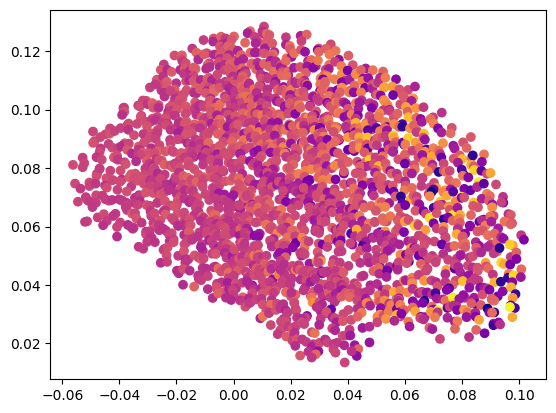

In [40]:
ind_show = 50
one_chan_leadfield = leadfield_fixed[ind_show]
vert_used = fwd_fixed['src'][0]['vertno']
fwd_to_plot = fwd_fixed['src'][0]['rr'][vert_used,:]
plt.scatter(fwd_to_plot[:,1],fwd_to_plot[:,2], c = one_chan_leadfield[:int(fwd_to_plot.shape[0])], cmap = 'plasma')

In [41]:
raw.info['ch_names'][ind_show]

'MEG 0511'

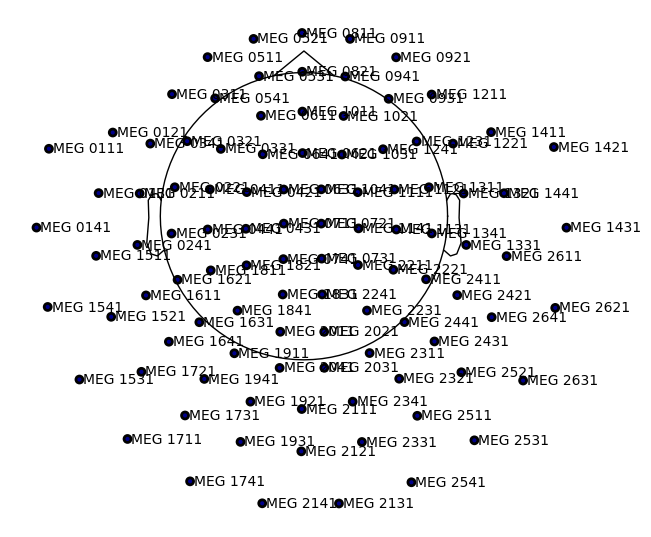

In [42]:
fig = raw.plot_sensors(show_names=True, ch_type='mag')

## Plot topographies

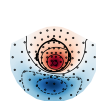

In [43]:
column=300
ind = mne.pick_types(raw.info, meg='mag',eeg=False)
info=mne.pick_info(raw.info, ind)
data=leadfield[ind,:]
fig=mne.viz.plot_topomap(data[:,column], pos = info)

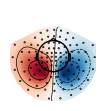

In [44]:
column=301
ind = mne.pick_types(raw.info, meg='mag',eeg=False)
info=mne.pick_info(raw.info, ind)
data=leadfield[ind,:]
fig=mne.viz.plot_topomap(data[:,column], pos = info)

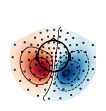

In [45]:
column=302
ind = mne.pick_types(raw.info, meg='mag',eeg=False)
info=mne.pick_info(raw.info, ind)
data=leadfield[ind,:]
fig=mne.viz.plot_topomap(data[:,column], pos = info)

## Dipole modeling

Interactive dipole simulator: https://mybinder.org/v2/gh/mne-tools/dipole-simulator/master?urlpath=voila%2Frender%2Findex.ipynb

In [46]:
amplitude = np.array([1]).reshape(1,)  
ori = np.array([1.,1.,1.]).reshape(1, 3)  
ori /= np.linalg.norm(ori)
pos=np.array([0.003, -0.01, 0.1])
pos = pos.reshape(1, 3)
gof = np.array([100]).reshape(1,)
dip = mne.Dipole(times=[0], pos=pos, ori=ori,
                     amplitude=amplitude, gof=gof)
fwd, _ = mne.make_forward_dipole(dip, bem=bem, info=info, trans=trans,
                                     verbose=True)
fwd = mne.convert_forward_solution(fwd, force_fixed=False, verbose=True)

Positions (in meters) and orientations
1 sources
Source space          : <SourceSpaces: [<discrete, n_used=1>] head coords, ~2 kB>
MRI -> head transform : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
Measurement data      : instance of Info
Conductor model   : instance of ConductorModel
Accurate field computations
Do computations in head coordinates
Free source orientations

Read 1 source spaces a total of 1 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    0.999310 0.009985 -0.035787      -3.17 mm
    0.012759 0.812405 0.582954       6.86 mm
    0.034894 -0.583008 0.811716      28.88 mm
    0.000000 0.000000 0.000000       1.00

Read 102 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
MEG coil def

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.5s finished


Computing MEG at 1 source location (free orientations)...

Finished.
    Changing to fixed-orientation forward solution with surface-based source orientations...
    [done]
    Cartesian source orientations...
    [done]


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


In [47]:
dip

<Dipole | n_times : 1, tmin : 0.000, tmax : 0.000>

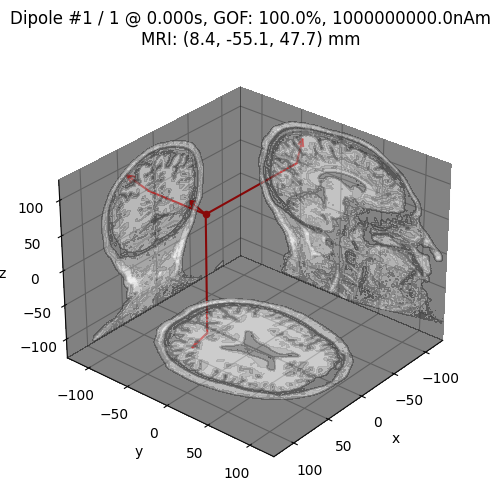

In [48]:
fig=dip.plot_locations(trans, 'sample', subjects_dir, mode='orthoview')


In [49]:
leadfield_dip = fwd['sol']['data']

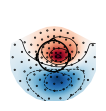

In [50]:
column=0
ind = mne.pick_types(raw.info, meg='mag',eeg=False)
info=mne.pick_info(raw.info, ind)
data=leadfield_dip
fig=mne.viz.plot_topomap(data[:,column], pos = info)

In [51]:
dipole_ori = ori.reshape(3, 1)
lf_fixed = leadfield_dip @ dipole_ori

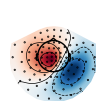

In [52]:
ind = mne.pick_types(raw.info, meg='mag',eeg=False)
info=mne.pick_info(raw.info, ind)
fig=mne.viz.plot_topomap(np.reshape(lf_fixed, [lf_fixed.shape[0],]), pos = info)